In [1]:
import pandas as pd

In [2]:
df = pd.read_csv("the-hungry-cowgirl-full-report.csv")

In [3]:
df.head()

,brand,recipe,recipe_kind,bases,proteins,toppings,sauce_cups,ingredients,nominal_g,nominal_oz,floor_g,legacy_verdict,legacy_final_g,legacy_final_oz,legacy_fill_pct,adaptive_status,adaptive_fill_pct,adaptive_alpha,cost
0,The Hungry Cowgirl,The Hungry Cowgirl Bowl,complete,Massaged Kale,Beef Shawarma,Black Beans,1,3,208,15.08,400,saturates short,365,28.62,95,underfilled,79,1.0,2.16
1,The Hungry Cowgirl,Hungry Cowboy Bowl,complete,Massaged Kale,Beef Shawarma,Black Beans,1,3,216,15.34,400,saturates short,365,28.62,95,underfilled,80,1.0,2.18
2,The Hungry Cowgirl,Basic Cowgirl Bowl,partial,Massaged Kale,Beef Shawarma,Black Beans,1,3,262,16.93,400,saturates short,365,28.62,95,no adjustment,78,0.0,2.16
3,The Hungry Cowgirl,Marinated Steak Bowl,partial,Massaged Kale,Beef Shawarma,Black Beans,1,3,216,15.34,400,saturates short,365,28.62,95,underfilled,80,1.0,2.18
4,The Hungry Cowgirl,Pollo Verde Asado Bowl,partial,Massaged Kale,Beef Shawarma,Black Beans,1,3,216,15.34,400,saturates short,365,28.62,95,underfilled,80,1.0,2.18


In [4]:
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import numpy as np

# Verdicts are states, so they get fixed status colors (same color everywhere below).
VERDICT_ORDER = ["fits", "over after ramping", "saturates short", "over as written"]
VERDICT_COLORS = {
    "fits": "#0ca30c",                # good
    "over after ramping": "#fab219",  # warning
    "saturates short": "#ec835a",     # serious
    "over as written": "#d03b3b",     # critical
}
INK, INK_2, GRID = "#0b0b0b", "#52514e", "#e4e3df"

plt.rcParams.update({
    "figure.dpi": 110,
    "figure.facecolor": "#fcfcfb",
    "axes.facecolor": "#fcfcfb",
    "axes.edgecolor": GRID,
    "axes.labelcolor": INK_2,
    "axes.titlecolor": INK,
    "axes.titleweight": "semibold",
    "axes.titlelocation": "left",
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.grid": True,
    "grid.color": GRID,
    "grid.linewidth": 0.8,
    "axes.axisbelow": True,
    "xtick.color": INK_2,
    "ytick.color": INK_2,
    "font.size": 10,
})

thousands = mticker.FuncFormatter(lambda x, _: f"{x:,.0f}")

## 1. Rows per legacy verdict

findfont: Failed to find font weight semibold for DejaVu Sans, now using 700.


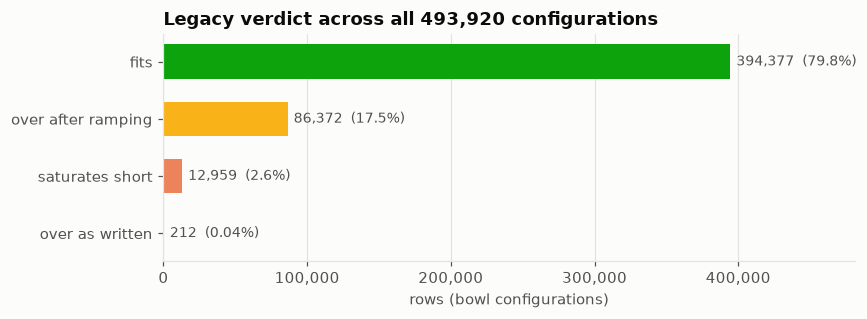

In [5]:
verdict_counts = df["legacy_verdict"].value_counts().reindex(VERDICT_ORDER)

fig, ax = plt.subplots(figsize=(8, 3))
bars = ax.barh(verdict_counts.index, verdict_counts.values,
               color=[VERDICT_COLORS[v] for v in verdict_counts.index], height=0.6)
ax.invert_yaxis()
ax.grid(axis="y", visible=False)
ax.xaxis.set_major_formatter(thousands)
ax.bar_label(bars, labels=[f"{n:,}  ({n / len(df):.{1 if n / len(df) >= 0.001 else 2}%})" for n in verdict_counts.values],
             padding=4, color=INK_2, fontsize=9)
ax.set_xlim(0, verdict_counts.max() * 1.22)
ax.set_xlabel("rows (bowl configurations)")
ax.set_title(f"Legacy verdict across all {len(df):,} configurations")
plt.tight_layout()
plt.show()

## 2. Rows per legacy verdict, faceted by recipe

Shared x-axis so bar lengths compare across recipes.

findfont: Failed to find font weight semibold for DejaVu Sans, now using 700.


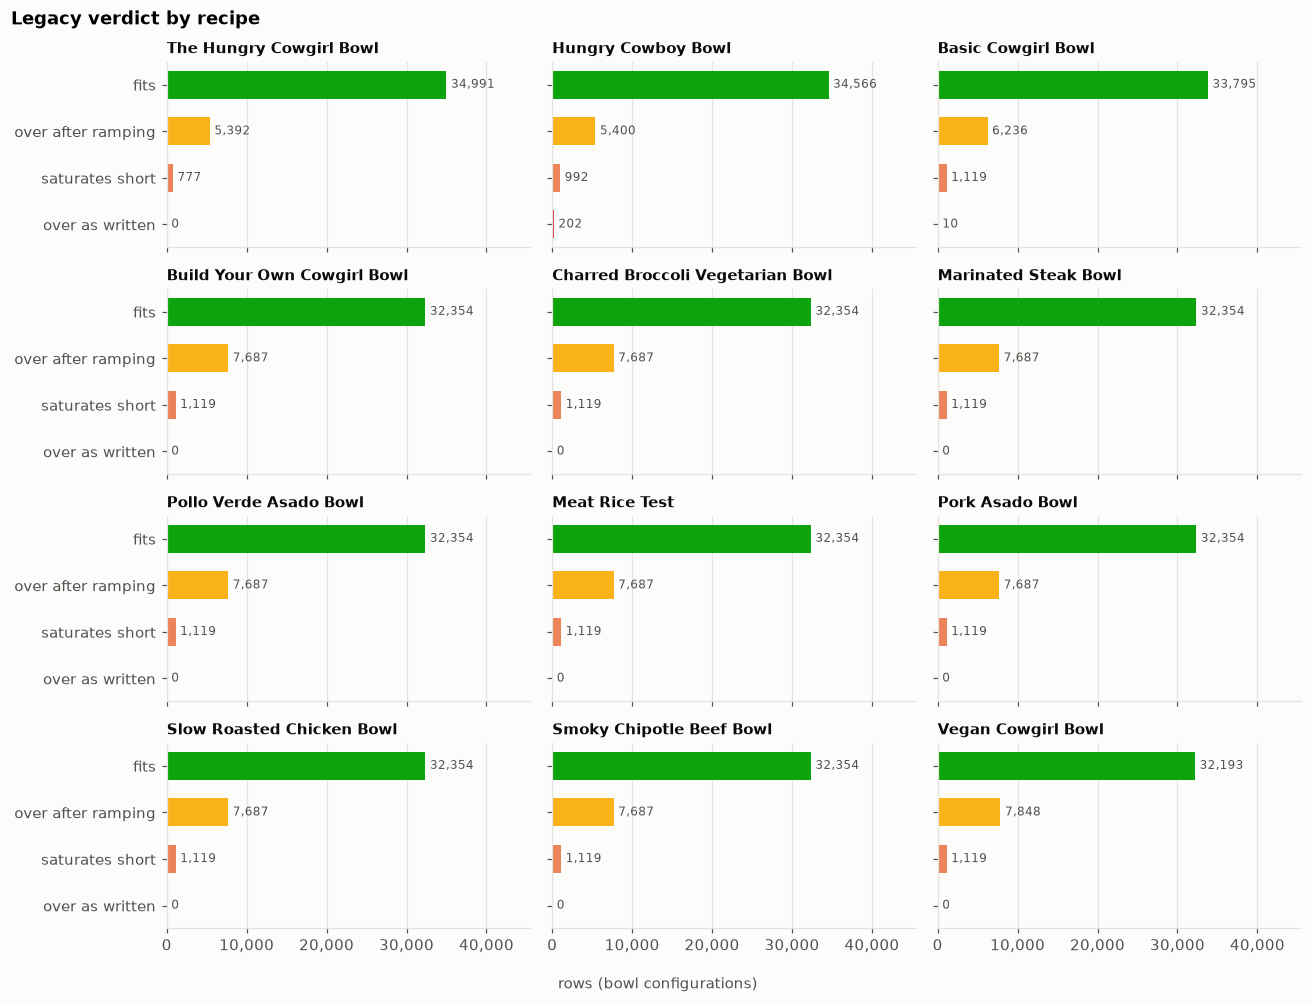

In [6]:
recipe_counts = (df.groupby(["recipe", "legacy_verdict"]).size()
                   .unstack(fill_value=0)
                   .reindex(columns=VERDICT_ORDER, fill_value=0))
# order facets by share of "fits", best first
recipe_counts = recipe_counts.loc[recipe_counts["fits"].div(recipe_counts.sum(axis=1))
                                  .sort_values(ascending=False).index]

ncols = 3
nrows = int(np.ceil(len(recipe_counts) / ncols))
fig, axes = plt.subplots(nrows, ncols, figsize=(12, 2.3 * nrows), sharex=True, sharey=True)
xmax = recipe_counts.values.max() * 1.3

for ax, (recipe, row) in zip(axes.flat, recipe_counts.iterrows()):
    bars = ax.barh(row.index, row.values,
                   color=[VERDICT_COLORS[v] for v in row.index], height=0.6)
    ax.bar_label(bars, labels=[f"{n:,}" for n in row.values], padding=3, color=INK_2, fontsize=8)
    ax.set_title(recipe, fontsize=10)
    ax.grid(axis="y", visible=False)
    ax.set_xlim(0, xmax)
    ax.xaxis.set_major_formatter(thousands)
axes.flat[0].invert_yaxis()  # shared y: inverting once flips all
for ax in axes.flat[len(recipe_counts):]:
    ax.set_visible(False)

fig.suptitle("Legacy verdict by recipe", x=0.01, ha="left", fontweight="semibold")
fig.supxlabel("rows (bowl configurations)", color=INK_2, fontsize=10)
plt.tight_layout()
plt.show()

Same data as a table (the `over as written` bars are too small to read on a linear axis):

In [7]:
recipe_counts.assign(total=recipe_counts.sum(axis=1),
                     fits_pct=lambda t: (t["fits"] / t["total"] * 100).round(1))

legacy_verdict,fits,over after ramping,saturates short,over as written,total,fits_pct
recipe,,,,,,
The Hungry Cowgirl Bowl,34991,5392,777,0,41160,85.0
Hungry Cowboy Bowl,34566,5400,992,202,41160,84.0
Basic Cowgirl Bowl,33795,6236,1119,10,41160,82.1
Build Your Own Cowgirl Bowl,32354,7687,1119,0,41160,78.6
Charred Broccoli Vegetarian Bowl,32354,7687,1119,0,41160,78.6
Marinated Steak Bowl,32354,7687,1119,0,41160,78.6
Pollo Verde Asado Bowl,32354,7687,1119,0,41160,78.6
Meat Rice Test,32354,7687,1119,0,41160,78.6
Pork Asado Bowl,32354,7687,1119,0,41160,78.6


## 3. Verdict mix by ingredient count

Share of rows in each verdict, per number of ingredients in the bowl. Fewer ingredients → the legacy portioner more often can't reach the floor.

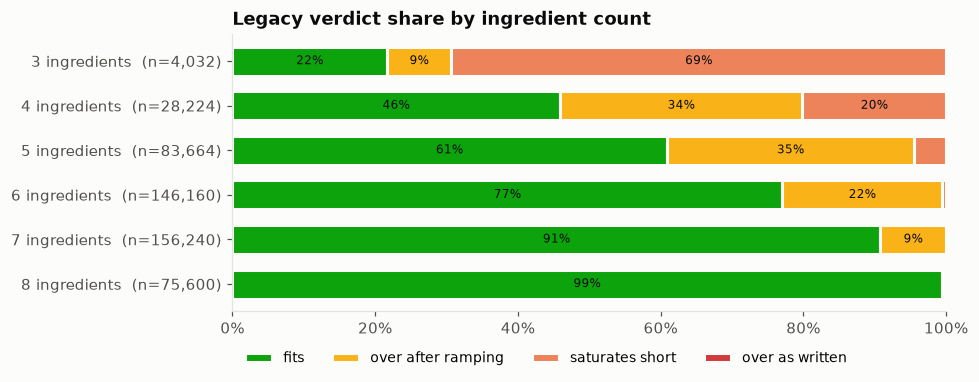

In [8]:
by_ing = pd.crosstab(df["ingredients"], df["legacy_verdict"], normalize="index")
by_ing = by_ing.reindex(columns=VERDICT_ORDER, fill_value=0)
n_by_ing = df["ingredients"].value_counts().sort_index()

fig, ax = plt.subplots(figsize=(9, 3.6))
left = np.zeros(len(by_ing))
ylabels = [f"{i} ingredients  (n={n_by_ing[i]:,})" for i in by_ing.index]
for v in VERDICT_ORDER:
    ax.barh(ylabels, by_ing[v].values, left=left, color=VERDICT_COLORS[v],
            height=0.65, edgecolor="#fcfcfb", linewidth=2, label=v)
    for y, (l, w) in enumerate(zip(left, by_ing[v].values)):
        if w >= 0.08:
            ax.text(l + w / 2, y, f"{w:.0%}", ha="center", va="center", fontsize=8, color=INK)
    left += by_ing[v].values
ax.invert_yaxis()
ax.grid(False)
ax.set_xlim(0, 1)
ax.xaxis.set_major_formatter(mticker.PercentFormatter(1.0))
ax.set_title("Legacy verdict share by ingredient count")
ax.legend(ncols=4, loc="upper left", bbox_to_anchor=(0, -0.1), frameon=False, fontsize=9)
plt.tight_layout()
plt.show()

## 4. Where do legacy verdicts land under the adaptive method?

Rows = legacy verdict, columns = adaptive status. Cell text is row count and share of that legacy verdict.

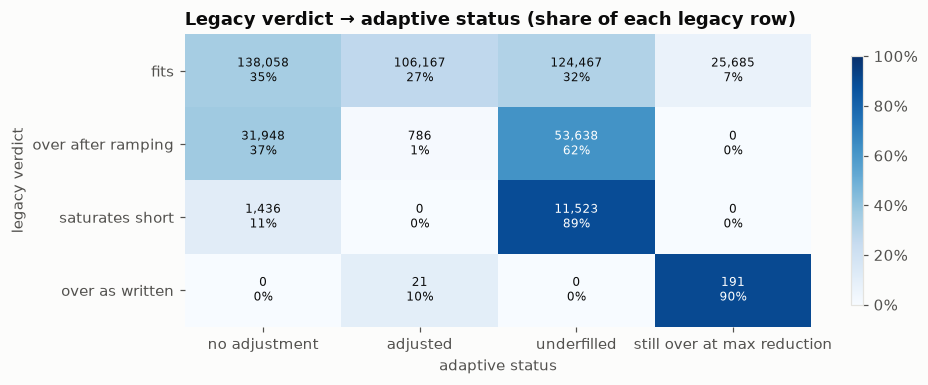

In [9]:
ADAPTIVE_ORDER = ["no adjustment", "adjusted", "underfilled", "still over at max reduction"]
xt = (pd.crosstab(df["legacy_verdict"], df["adaptive_status"])
        .reindex(index=VERDICT_ORDER, columns=ADAPTIVE_ORDER, fill_value=0))
row_share = xt.div(xt.sum(axis=1), axis=0)

fig, ax = plt.subplots(figsize=(9, 3.6))
im = ax.imshow(row_share.values, cmap="Blues", vmin=0, vmax=1, aspect="auto")
ax.set_xticks(range(len(xt.columns)), xt.columns)
ax.set_yticks(range(len(xt.index)), xt.index)
ax.grid(False)
for s in ax.spines.values():
    s.set_visible(False)
for i in range(xt.shape[0]):
    for j in range(xt.shape[1]):
        share = row_share.iat[i, j]
        ax.text(j, i, f"{xt.iat[i, j]:,}\n{share:.0%}", ha="center", va="center", fontsize=8,
                color="white" if share > 0.55 else INK)
ax.set_xlabel("adaptive status")
ax.set_ylabel("legacy verdict")
ax.set_title("Legacy verdict → adaptive status (share of each legacy row)")
fig.colorbar(im, ax=ax, format=mticker.PercentFormatter(1.0), shrink=0.85)
plt.tight_layout()
plt.show()

## 5. Fill % distribution: legacy vs adaptive

Two panels on one shared x-axis (not overlaid) so each distribution reads on its own.

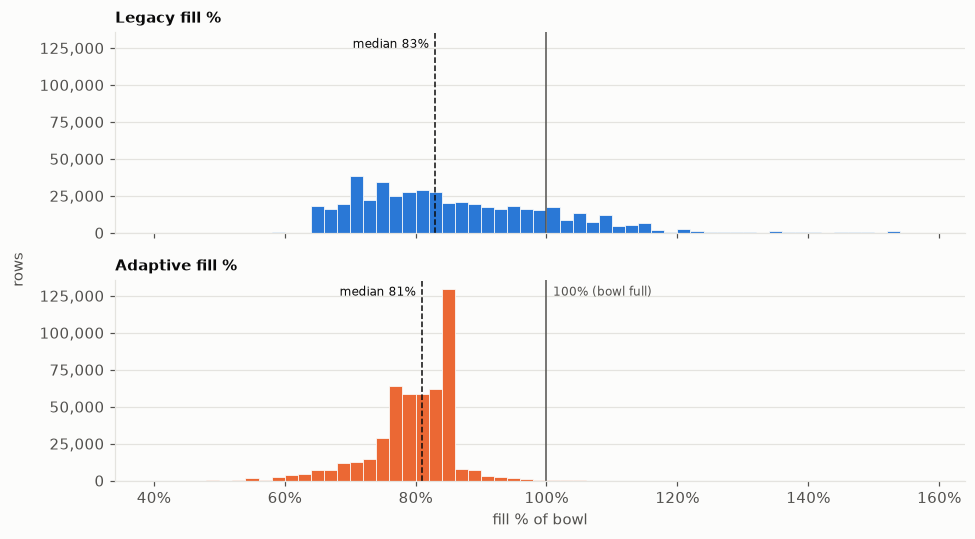

In [10]:
bins = np.arange(40, 160, 2)
fig, axes = plt.subplots(2, 1, figsize=(9, 5), sharex=True, sharey=True)
for ax, col, label, color in [
    (axes[0], "legacy_fill_pct", "Legacy", "#2a78d6"),
    (axes[1], "adaptive_fill_pct", "Adaptive", "#eb6834"),
]:
    ax.hist(df[col], bins=bins, color=color, edgecolor="#fcfcfb", linewidth=0.5)
    med = df[col].median()
    ax.axvline(med, color=INK, linewidth=1, linestyle="--")
    ax.text(med - 1, 0.92, f"median {med:.0f}%", transform=ax.get_xaxis_transform(),
            ha="right", fontsize=8, color=INK)
    ax.axvline(100, color=INK_2, linewidth=1)
    ax.set_title(f"{label} fill %", fontsize=10)
    ax.yaxis.set_major_formatter(thousands)
    ax.grid(axis="x", visible=False)
axes[1].text(101, 0.92, "100% (bowl full)", transform=axes[1].get_xaxis_transform(),
             fontsize=8, color=INK_2)
axes[1].xaxis.set_major_formatter(mticker.PercentFormatter(100))
axes[1].set_xlabel("fill % of bowl")
fig.supylabel("rows", color=INK_2, fontsize=10)
plt.tight_layout()
plt.show()

## 6. Verdict by base

`bases` is a `|`-separated list. Each base is classed as a **green** (Romaine, Kale) or a **grain** (White Rice, Mexican Rice, Brown Rice and Lentils). A 2-base bowl is `green`, `grain`, or `green + grain` when it mixes one of each.

In [11]:
GREENS = {"Romaine Base", "Massaged Kale"}
GRAINS = {"White Rice", "Mexican Rice", "Brown Rice and Lentils"}

def base_type(bases):
    kinds = {"green" if b in GREENS else "grain" if b in GRAINS else "other" for b in bases}
    return " + ".join(sorted(kinds, key=["green", "grain", "other"].index))

base_lists = df["bases"].str.split("|")
df["base_count"] = base_lists.str.len()
df["base_type"] = base_lists.map(base_type)
df["base_group"] = (df["base_count"].map({1: "1 base", 2: "2 bases"}).fillna(df["base_count"].astype(str) + " bases")
                    + " · " + df["base_type"])
assert (df["base_type"] != "other").all(), df.loc[df["base_type"].str.contains("other"), "bases"].unique()

df.groupby(["base_count", "base_type"]).size().rename("rows").to_frame()

rows
base_count base_type            
1          grain           98784
           green           98784
2          grain           49392
           green           49392
           green + grain  197568

In [12]:
def verdict_share_chart(col, title, order=None, label=None, sort_by_fits=False, figsize=None):
    """100% stacked horizontal bar of legacy_verdict share for each value of `col`."""
    share = pd.crosstab(df[col], df["legacy_verdict"], normalize="index").reindex(columns=VERDICT_ORDER, fill_value=0)
    if order is not None:
        share = share.reindex(order)
    elif sort_by_fits:
        share = share.sort_values("fits", ascending=False)
    n = df[col].value_counts()
    label = label or str
    ylabels = [f"{label(k)}  (n={n[k]:,})" for k in share.index]

    fig, ax = plt.subplots(figsize=figsize or (9, 0.55 * len(share) + 1.4))
    left = np.zeros(len(share))
    for v in VERDICT_ORDER:
        ax.barh(ylabels, share[v].values, left=left, color=VERDICT_COLORS[v],
                height=0.65, edgecolor="#fcfcfb", linewidth=2, label=v)
        for y, (l, w) in enumerate(zip(left, share[v].values)):
            if w >= 0.08:
                ax.text(l + w / 2, y, f"{w:.0%}", ha="center", va="center", fontsize=8, color=INK)
        left += share[v].values
    ax.invert_yaxis()
    ax.grid(False)
    ax.set_xlim(0, 1)
    ax.xaxis.set_major_formatter(mticker.PercentFormatter(1.0))
    ax.set_title(title)
    ax.legend(ncols=4, loc="upper left", bbox_to_anchor=(0, -0.12), frameon=False, fontsize=9)
    plt.tight_layout()
    plt.show()
    return share

### 6a. One base vs two

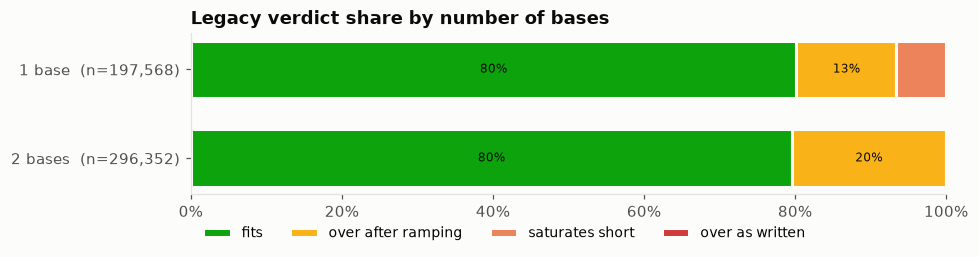

In [13]:
verdict_share_chart("base_count", "Legacy verdict share by number of bases",
                    label=lambda k: f"{k} base" + ("s" if k > 1 else ""));

### 6b. Base count × green / grain

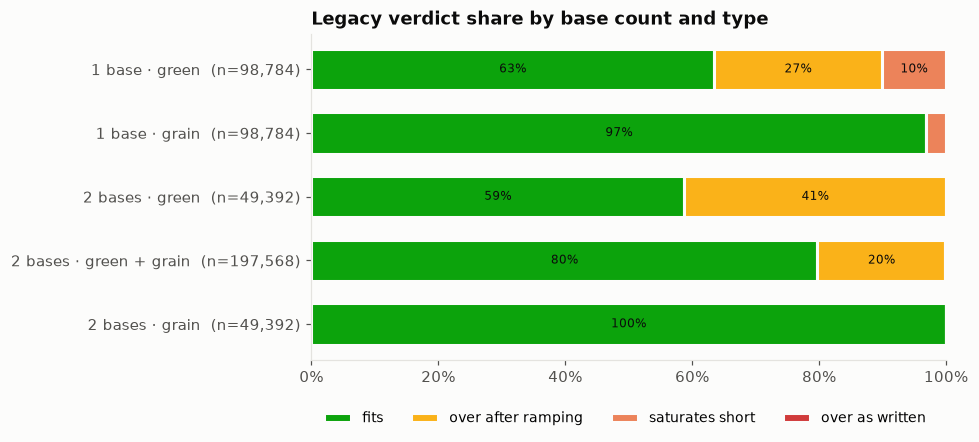

In [14]:
verdict_share_chart("base_group", "Legacy verdict share by base count and type",
                    order=["1 base · green", "1 base · grain",
                           "2 bases · green", "2 bases · green + grain", "2 bases · grain"]);

### 6c. Every base combination

Sorted by share of `fits`.

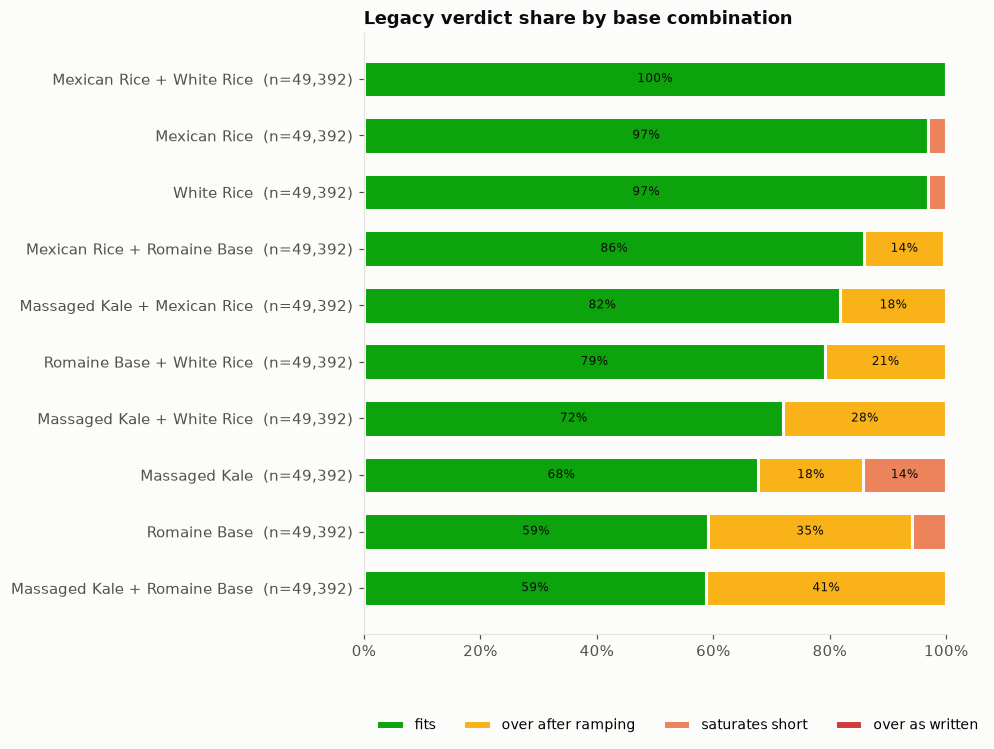

In [15]:
verdict_share_chart("bases", "Legacy verdict share by base combination",
                    label=lambda k: k.replace("|", " + "), sort_by_fits=True);